In [1]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
df = pd.read_csv("data/Nassau Candy Distributor.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


# Data Understanding

In this phase, we explore the structure and quality of the Nassau Candy Distributor dataset. This includes checking the number of records, data types, missing values, duplicate records, and statistical summaries. Understanding the dataset helps prepare it for cleaning, feature engineering, and predictive modeling.

In [3]:
df.shape

(10194, 18)

In [4]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 11  Region          10194 non-null  str    
 12  Product ID      10194 non-null  str    
 13  Product Name    10194 non-null  str    
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null  float64
dt

In [6]:
df.describe()

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [7]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## Data Quality Assessment

The dataset contains **10,194 records** and **18 features**. A data quality assessment was performed before analysis.

### Observations:
- No missing values were found.
- No duplicate records were found.
- The dataset is complete and suitable for analysis without requiring imputation or duplicate removal.

### Conclusion:
The dataset is clean and ready for feature engineering, exploratory data analysis, and predictive modeling.

In [9]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [10]:
df["Lead_Time"] = (df["Ship Date"] - df["Order Date"]).dt.days

In [11]:
df[["Order Date", "Ship Date", "Lead_Time"]].head()

,Order Date,Ship Date,Lead_Time
0,2024-01-03,2026-06-30,909
1,2024-01-04,2026-07-01,909
2,2024-01-04,2026-07-01,909
3,2024-01-04,2026-07-01,909
4,2024-01-05,2026-07-05,912


In [12]:
df["Lead_Time"].describe()

count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Lead_Time, dtype: float64

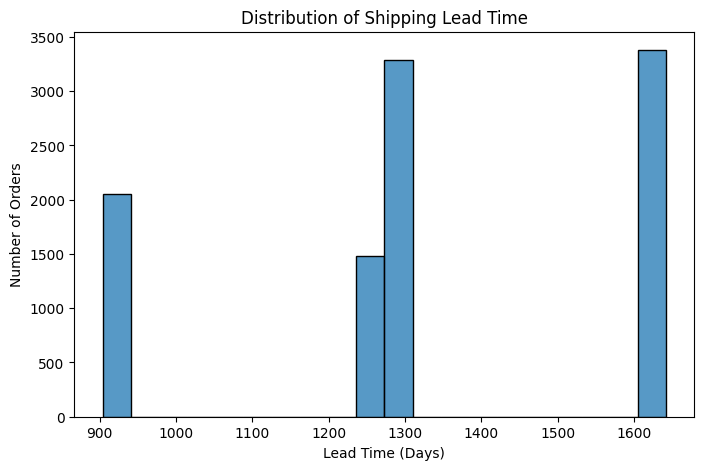

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df["Lead_Time"], bins=20)

plt.title("Distribution of Shipping Lead Time")

plt.xlabel("Lead Time (Days)")

plt.ylabel("Number of Orders")

plt.show()

## Feature Engineering – Shipping Lead Time

A new feature called **Lead_Time** was created by calculating the difference between the shipment date and the order date.

This feature represents the total number of days required to deliver an order and serves as one of the most important variables in the shipping optimization model.

In [14]:
factory_map = {
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows": "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious": "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate": "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel": "Wicked Choccy's",
    "Laffy Taffy": "Sugar Shack",
    "SweeTARTS": "Sugar Shack",
    "Nerds": "Sugar Shack",
    "Fun Dip": "Sugar Shack",
    "Fizzy Lifting Drinks": "Sugar Shack",
    "Everlasting Gobstopper": "Secret Factory",
    "Hair Toffee": "The Other Factory",
    "Lickable Wallpaper": "Secret Factory",
    "Wonka Gum": "Secret Factory",
    "Kazookles": "The Other Factory"
}

df["Factory"] = df["Product Name"].map(factory_map)

df[["Product Name", "Factory"]].head()

,Product Name,Factory
0,Wonka Bar - Milk Chocolate,Wicked Choccy's
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's


In [15]:
df["Factory"].value_counts()

Factory
Lot's O' Nuts        5692
Wicked Choccy's      4152
Secret Factory        217
The Other Factory     100
Sugar Shack            33
Name: count, dtype: int64

# Factory Mapping

Each product was mapped to its manufacturing factory using the predefined product–factory relationship provided by Nassau Candy Distributor.

This mapping enables simulation of alternative factory assignments and forms the foundation of the shipping optimization recommendation engine.

In [16]:
df[df["Factory"].isnull()][["Product Name"]]

,Product Name


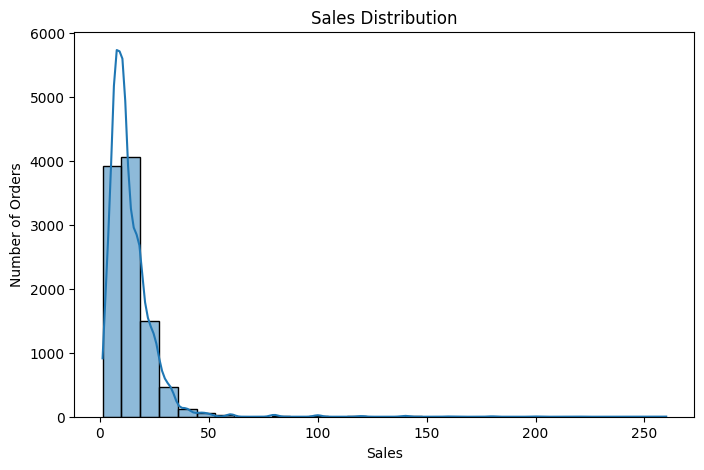

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["Sales"], bins=30, kde=True)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Number of Orders")
plt.show()

## Sales Distribution

The histogram shows the distribution of sales across all customer orders.
Most orders have relatively low sales values, while only a few orders have very high sales.
This indicates a positively skewed distribution, which is common in retail datasets.

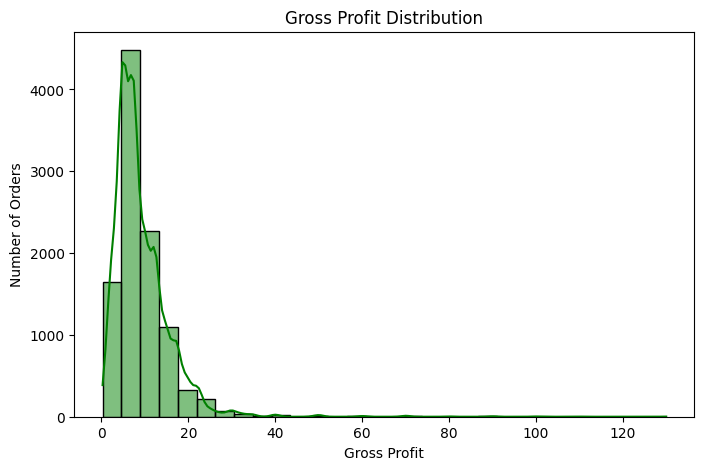

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df["Gross Profit"], bins=30, kde=True, color="green")
plt.title("Gross Profit Distribution")
plt.xlabel("Gross Profit")
plt.ylabel("Number of Orders")
plt.show()

## Gross Profit Distribution

The gross profit distribution follows a similar pattern to sales.
Most transactions generate moderate profit, while only a few produce very high profits.
This information helps identify the profitability characteristics of the business.

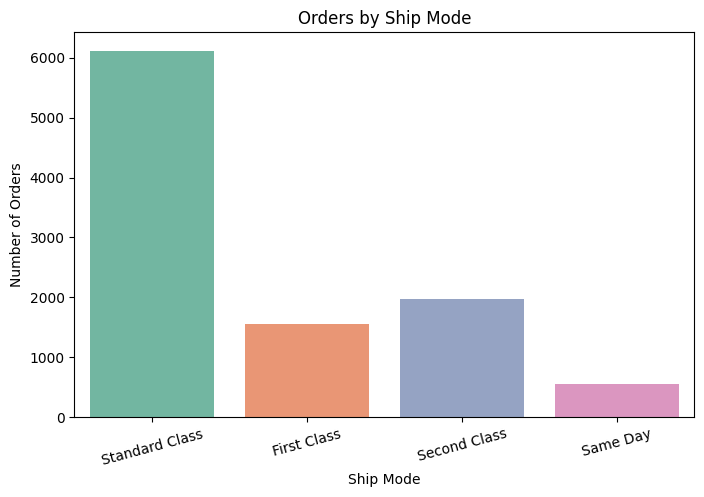

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Ship Mode",
    hue="Ship Mode",
    palette="Set2",
    legend=False
)

plt.title("Orders by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Number of Orders")
plt.xticks(rotation=15)

plt.show()

## Orders by Ship Mode

The visualization shows the number of orders shipped through different shipping modes.
Standard Class accounts for the majority of shipments, indicating that customers prefer economical shipping options.
Premium shipping methods such as First Class and Same Day are used less frequently.

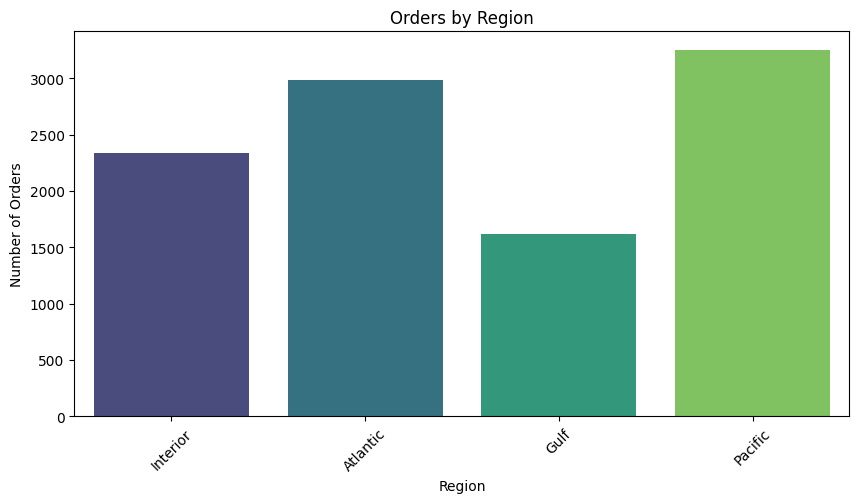

In [20]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Region",
    hue="Region",
    palette="viridis",
    legend=False
)

plt.title("Orders by Region")
plt.xlabel("Region")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.show()

## Orders by Region

The chart presents the distribution of customer orders across different regions.
Some regions contribute significantly more orders than others, indicating higher market demand.
These regional differences are useful for optimizing factory allocation and shipping strategies.

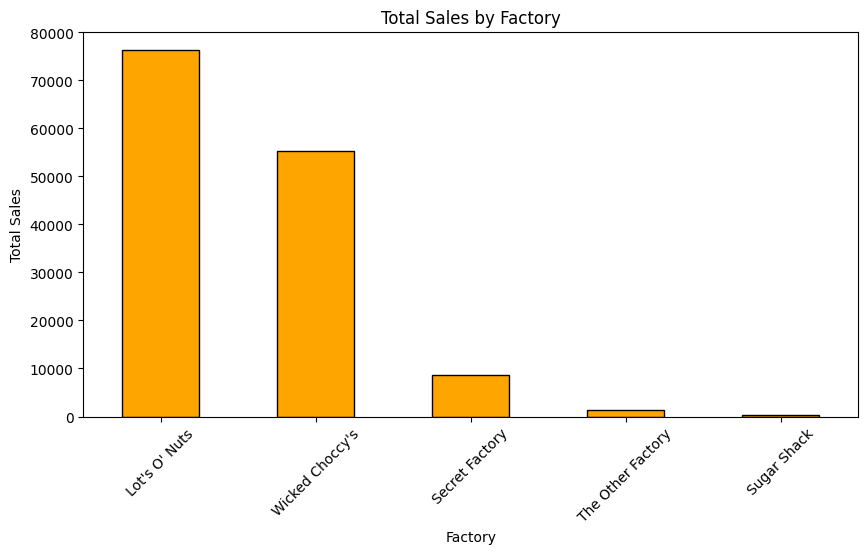

In [21]:
factory_sales = df.groupby("Factory")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
factory_sales.plot(kind="bar", color="orange", edgecolor="black")

plt.title("Total Sales by Factory")
plt.xlabel("Factory")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

## Sales by Factory

This chart shows the total sales generated by each manufacturing factory.
It helps identify which factory contributes the most to overall revenue.
The company can use this information for production planning and inventory management.

## Sales by Factory

The chart shows the total sales generated by each factory.

- Lot's O' Nuts has the highest sales.
- Wicked Choccy's is the second highest contributor.
- Secret Factory, The Other Factory, and Sugar Shack contribute comparatively lower sales.

This analysis helps identify the factories that generate the highest revenue and supports production planning.

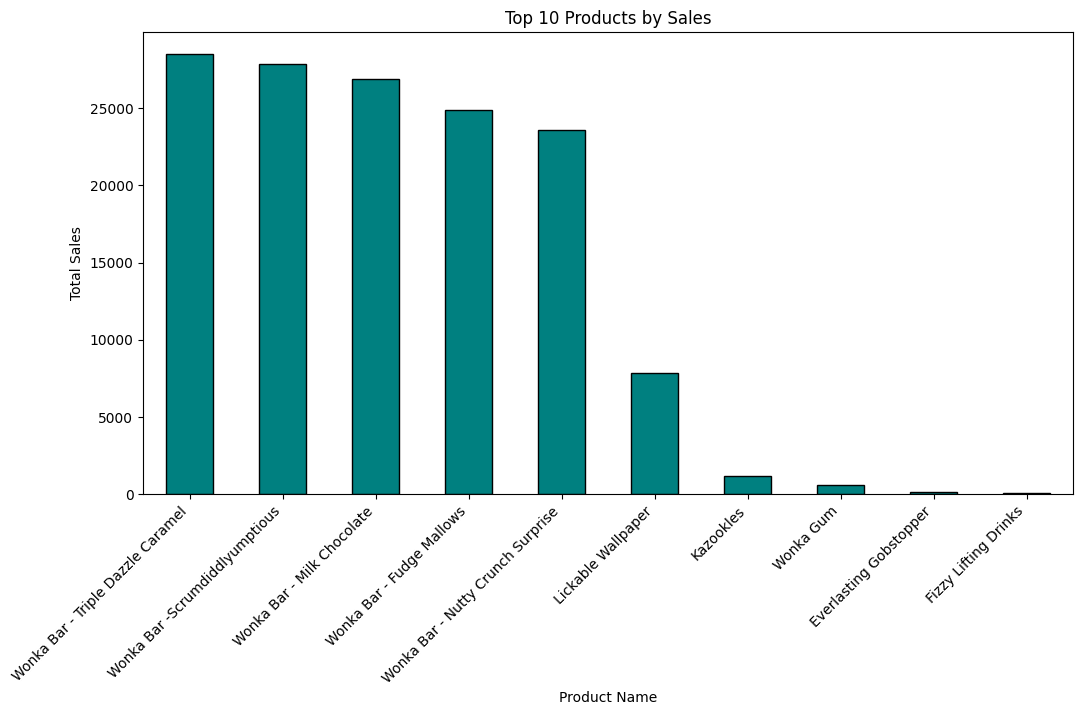

In [22]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_products.plot(kind="bar", color="teal", edgecolor="black")

plt.title("Top 10 Products by Sales")
plt.xlabel("Product Name")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")

plt.show()

## Top 10 Products by Sales

The chart highlights the top-selling products based on total sales.

- Wonka Bar - Triple Dazzle Caramel is the highest-selling product.
- Wonka Bar - Scrumdiddlyumptious and Wonka Bar - Milk Chocolate are also among the top contributors.
- Products such as Everlasting Gobstopper and Fizzy Lifting Drinks have comparatively lower sales.

This analysis helps identify the most popular products and supports inventory planning and marketing decisions.

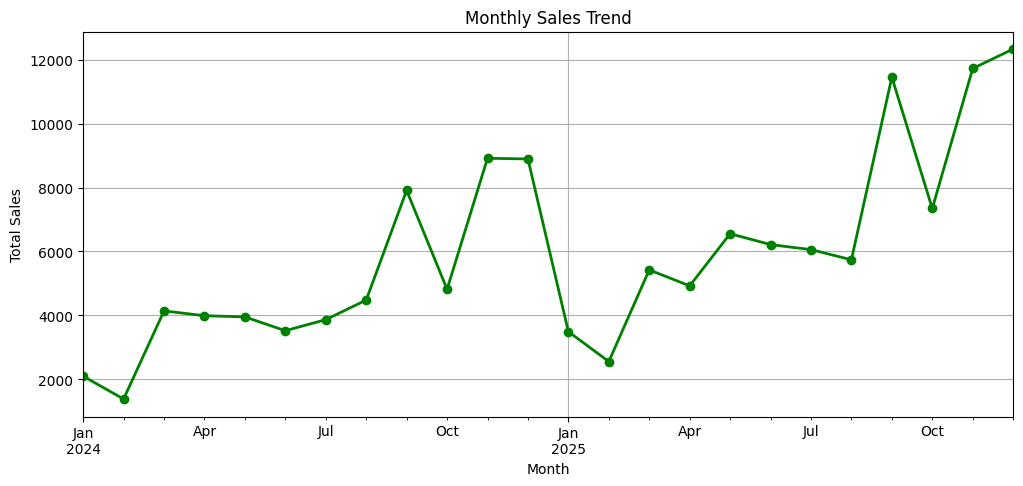

In [23]:
# Monthly Sales Trend

monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot(marker='o', linewidth=2, color='green')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(True)
plt.show()

## Monthly Sales Trend

This visualization shows how total sales change over time.

It helps identify seasonal demand, peak sales periods, and business trends.
The analysis can support forecasting and future sales planning.

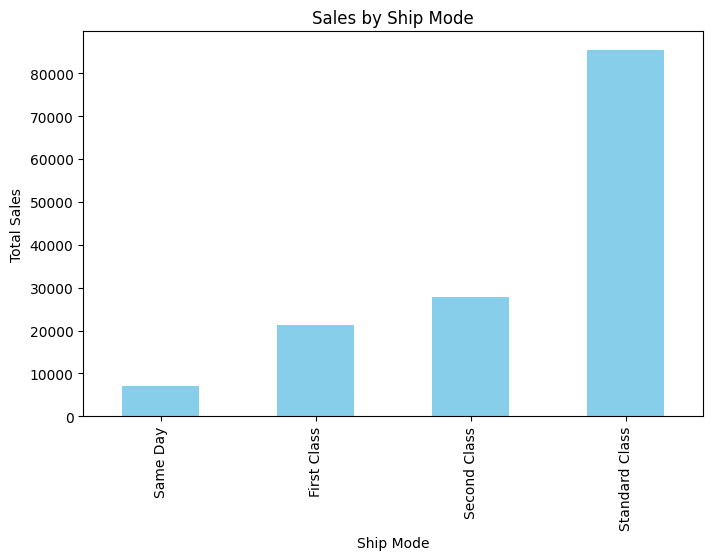

In [24]:
plt.figure(figsize=(8,5))

df.groupby("Ship Mode")["Sales"].sum().sort_values().plot(
    kind="bar",
    color="skyblue"
)

plt.title("Sales by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Total Sales")
plt.show()

### Sales by Ship Mode

This chart compares total sales across different shipping methods.
It helps identify which shipping mode is used for the highest-value orders.

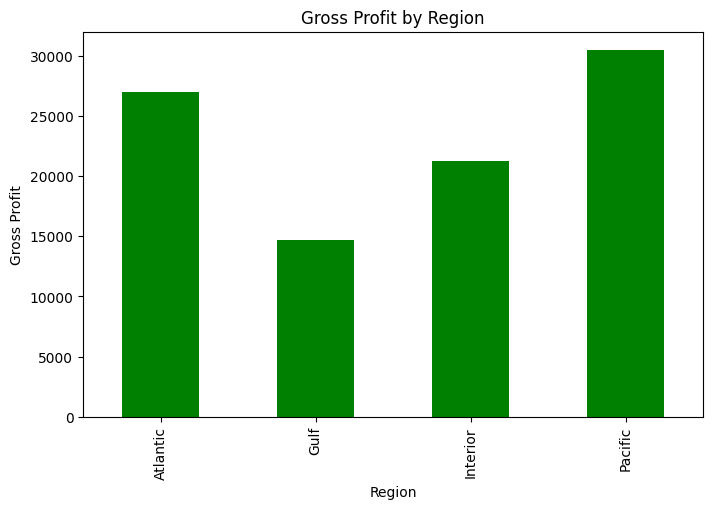

In [25]:
plt.figure(figsize=(8,5))

df.groupby("Region")["Gross Profit"].sum().plot(
    kind="bar",
    color="green"
)

plt.title("Gross Profit by Region")
plt.xlabel("Region")
plt.ylabel("Gross Profit")
plt.show()

### Gross Profit by Region

This graph shows which region generates the highest profit.
It helps identify the most profitable market.

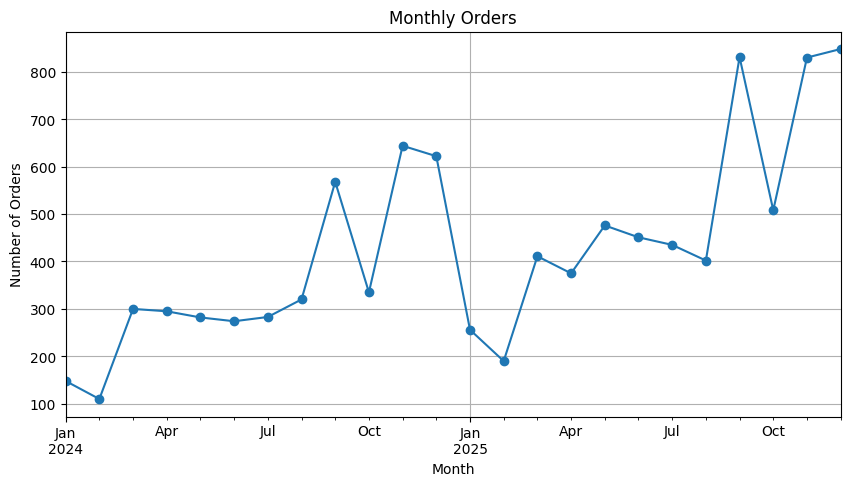

In [26]:
df["Month"] = df["Order Date"].dt.to_period("M")

monthly_orders = df.groupby("Month").size()

plt.figure(figsize=(10,5))

monthly_orders.plot(marker="o")

plt.title("Monthly Orders")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.grid(True)

plt.show()

### Monthly Orders

The number of customer orders is analyzed month by month.
This helps identify seasonal demand.

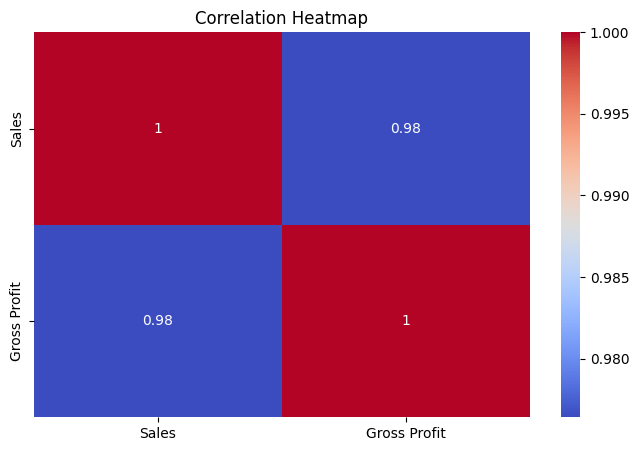

In [27]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.heatmap(
    df[["Sales","Gross Profit"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

### Correlation Heatmap

The heatmap shows the relationship between Sales and Gross Profit.
A strong positive correlation indicates that higher sales generally produce higher profit.

# Conclusion

The exploratory data analysis of the Nassau Candy Distributor dataset reveals important business insights.

• Sales increased steadily over time, with higher performance in late 2025.
• Lot's O' Nuts and Wicked Choccy's contributed the largest share of total sales.
• A few products generated the majority of revenue.
• The Pacific region handled the highest number of orders.
• Gross profit follows a positively skewed distribution, indicating that most orders generate moderate profit while only a few generate very high profit.
• These findings can help improve inventory planning, factory allocation, and business decision-making.

In [28]:
ml_df = df.copy()

In [29]:
ml_df = ml_df[[
    "Factory",
    "Region",
    "Ship Mode",
    "Sales",
    "Units",
    "Gross Profit",
    "Cost",
    "Order Date",
    "Ship Date",
    "Product Name"
]]

In [30]:
ml_df["Lead Time"] = (
    ml_df["Ship Date"] - ml_df["Order Date"]
).dt.days

In [31]:
ml_df[["Order Date", "Ship Date", "Lead Time"]].head()

,Order Date,Ship Date,Lead Time
0,2024-01-03,2026-06-30,909
1,2024-01-04,2026-07-01,909
2,2024-01-04,2026-07-01,909
3,2024-01-04,2026-07-01,909
4,2024-01-05,2026-07-05,912


In [32]:
ml_df.isnull().sum()

Factory         0
Region          0
Ship Mode       0
Sales           0
Units           0
Gross Profit    0
Cost            0
Order Date      0
Ship Date       0
Product Name    0
Lead Time       0
dtype: int64

In [33]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in ["Factory", "Region", "Ship Mode", "Product Name"]:
    ml_df[col] = encoder.fit_transform(ml_df[col])

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

ml_df[["Sales", "Units", "Gross Profit", "Cost"]] = scaler.fit_transform(
    ml_df[["Sales", "Units", "Gross Profit", "Cost"]]
)

In [35]:
ml_df.head()

,Factory,Region,Ship Mode,Sales,Units,Gross Profit,Cost,Order Date,Ship Date,Product Name,Lead Time
0,4,2,3,-0.653283,-0.804161,-0.744565,-0.486444,2024-01-03,2026-06-30,10,909
1,4,2,3,-0.565104,-0.804161,-0.642208,-0.423220,2024-01-04,2026-07-01,12,909
2,0,2,3,-0.303210,-0.355370,-0.255358,-0.344191,2024-01-04,2026-07-01,11,909
3,0,2,3,-0.274110,-0.355370,-0.250843,-0.284919,2024-01-04,2026-07-01,13,909
4,4,0,3,-0.234429,-0.355370,-0.273421,-0.166374,2024-01-05,2026-07-05,12,912


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = ml_df[["Factory", "Region", "Ship Mode", "Product Name", "Sales", "Units", "Gross Profit", "Cost"]]

y = ml_df["Lead Time"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance")
print("-----------------------------")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 4))

Linear Regression Performance
-----------------------------
MAE : 215.01
RMSE: 266.12
R² Score: -0.0014


In [38]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
rf_pred = rf_model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
r2 = r2_score(y_test, rf_pred)

print("Random Forest Performance")
print("-------------------------")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 4))

Random Forest Performance
-------------------------
MAE : 224.95
RMSE: 277.17
R² Score: -0.0863


In [40]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)

gb_model.fit(X_train, y_train)

print("Gradient Boosting Model Trained Successfully!")

Gradient Boosting Model Trained Successfully!


In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

gb_pred = gb_model.predict(X_test)

mae = mean_absolute_error(y_test, gb_pred)
rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting Performance")
print("----------------------------")
print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R² Score:", round(r2,4))

Gradient Boosting Performance
----------------------------
MAE : 216.06
RMSE: 267.83
R² Score: -0.0143


In [42]:
factory_locations = {
    "Lot's O' Nuts": (32.881893, -111.768036),
    "Wicked Choccy's": (32.076176, -81.088371),
    "Sugar Shack": (48.119140, -96.181150),
    "Secret Factory": (41.446333, -90.565487),
    "The Other Factory": (35.117500, -89.971107)
}

factory_df = pd.DataFrame(
    factory_locations.items(),
    columns=["Factory", "Coordinates"]
)

factory_df

,Factory,Coordinates
0,Lot's O' Nuts,"(32.881893, -111.768036)"
1,Wicked Choccy's,"(32.076176, -81.088371)"
2,Sugar Shack,"(48.11914, -96.18115)"
3,Secret Factory,"(41.446333, -90.565487)"
4,The Other Factory,"(35.1175, -89.971107)"


In [43]:
recommendation_df = df[[
    "Product Name",
    "Factory",
    "Region",
    "Ship Mode",
    "Sales",
    "Gross Profit"
]].copy()

recommendation_df.head()

,Product Name,Factory,Region,Ship Mode,Sales,Gross Profit
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,Interior,Standard Class,6.50,4.22
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Interior,Standard Class,7.50,4.90
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Interior,Standard Class,10.47,7.47
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Interior,Standard Class,10.80,7.50
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Atlantic,Standard Class,11.25,7.35


In [44]:
# Calculate average Gross Profit for each Product-Factory combination
factory_performance = (
    recommendation_df
    .groupby(["Product Name", "Factory"])["Gross Profit"]
    .mean()
    .reset_index()
)

factory_performance.head()

,Product Name,Factory,Gross Profit
0,Everlasting Gobstopper,Secret Factory,34.666667
1,Fizzy Lifting Drinks,Sugar Shack,7.875000
2,Fun Dip,Sugar Shack,1.600000
3,Hair Toffee,The Other Factory,14.875000
4,Kazookles,The Other Factory,0.966146


In [45]:
# Select the best factory for each product
best_factory = (
    factory_performance
    .sort_values("Gross Profit", ascending=False)
    .groupby("Product Name")
    .first()
    .reset_index()
)

best_factory.rename(columns={
    "Factory": "Recommended Factory",
    "Gross Profit": "Average Gross Profit"
}, inplace=True)

best_factory

,Product Name,Recommended Factory,Average Gross Profit
0,Everlasting Gobstopper,Secret Factory,34.666667
1,Fizzy Lifting Drinks,Sugar Shack,7.875000
2,Fun Dip,Sugar Shack,1.600000
3,Hair Toffee,The Other Factory,14.875000
4,Kazookles,The Other Factory,0.966146
5,Laffy Taffy,Sugar Shack,3.348000
6,Lickable Wallpaper,Secret Factory,41.808511
7,Nerds,Sugar Shack,1.750000
8,SweeTARTS,Sugar Shack,2.870000
9,Wonka Bar - Fudge Mallows,Lot's O' Nuts,9.127393


In [46]:
from sklearn.preprocessing import MinMaxScaler

score_df = recommendation_df.copy()

scaler = MinMaxScaler()

score_df[["Sales_Score", "Profit_Score"]] = scaler.fit_transform(
    score_df[["Sales", "Gross Profit"]]
)

score_df.head()

,Product Name,Factory,Region,Ship Mode,Sales,Gross Profit,Sales_Score,Profit_Score
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,Interior,Standard Class,6.50,4.22,0.020290,0.030597
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Interior,Standard Class,7.50,4.90,0.024155,0.035838
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Interior,Standard Class,10.47,7.47,0.035633,0.055645
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Interior,Standard Class,10.80,7.50,0.036908,0.055877
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Atlantic,Standard Class,11.25,7.35,0.038647,0.054721


In [47]:
ship_scores = {
    "Same Day": 1.0,
    "First Class": 0.8,
    "Second Class": 0.6,
    "Standard Class": 0.4
}

score_df["ShipMode_Score"] = score_df["Ship Mode"].map(ship_scores)

In [48]:
region_scores = {
    "Atlantic": 1.0,
    "Interior": 1.0,
    "Pacific": 1.0
}

score_df["Region_Score"] = score_df["Region"].map(region_scores)

In [49]:
score_df["Recommendation Score"] = (
    0.40 * score_df["Profit_Score"] +
    0.30 * score_df["Sales_Score"] +
    0.20 * score_df["ShipMode_Score"] +
    0.10 * score_df["Region_Score"]
)

score_df[[
    "Product Name",
    "Factory",
    "Recommendation Score"
]].head()

,Product Name,Factory,Recommendation Score
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,0.198326
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,0.201582
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,0.212948
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,0.213423
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,0.213482


In [50]:
all_factories = [
    "Lot's O' Nuts",
    "Wicked Choccy's",
    "Sugar Shack",
    "Secret Factory",
    "The Other Factory"
]

In [51]:
simulation = []

for _, row in score_df.iterrows():
    for factory in all_factories:
        simulation.append({
            "Product Name": row["Product Name"],
            "Current Factory": row["Factory"],
            "Simulated Factory": factory,
            "Recommendation Score": row["Recommendation Score"],
            "Sales": row["Sales"],
            "Gross Profit": row["Gross Profit"]
        })

simulation_df = pd.DataFrame(simulation)

simulation_df.head(10)

,Product Name,Current Factory,Simulated Factory,Recommendation Score,Sales,Gross Profit
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,0.198326,6.5,4.22
1,Wonka Bar - Milk Chocolate,Wicked Choccy's,Wicked Choccy's,0.198326,6.5,4.22
2,Wonka Bar - Milk Chocolate,Wicked Choccy's,Sugar Shack,0.198326,6.5,4.22
3,Wonka Bar - Milk Chocolate,Wicked Choccy's,Secret Factory,0.198326,6.5,4.22
4,Wonka Bar - Milk Chocolate,Wicked Choccy's,The Other Factory,0.198326,6.5,4.22
5,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,0.201582,7.5,4.90
6,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Wicked Choccy's,0.201582,7.5,4.90
7,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Sugar Shack,0.201582,7.5,4.90
8,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Secret Factory,0.201582,7.5,4.90
9,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,The Other Factory,0.201582,7.5,4.90


In [52]:
final_recommendation = (
    score_df.groupby(["Product Name", "Factory"])
    .agg({
        "Recommendation Score": "mean",
        "Sales": "mean",
        "Gross Profit": "mean"
    })
    .reset_index()
)

final_recommendation = final_recommendation.sort_values(
    by="Recommendation Score",
    ascending=False
)

final_recommendation.head(15)

,Product Name,Factory,Recommendation Score,Sales,Gross Profit
6,Lickable Wallpaper,Secret Factory,0.437185,83.617021,41.808511
0,Everlasting Gobstopper,Secret Factory,0.380937,43.333333,34.666667
3,Hair Toffee,The Other Factory,0.284484,19.125000,14.875000
13,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,0.249378,13.505233,9.378634
11,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,0.249294,13.024834,9.292790
12,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,0.248856,14.136476,9.235831
1,Fizzy Lifting Drinks,Sugar Shack,0.248146,13.125000,7.875000
9,Wonka Bar - Fudge Mallows,Lot's O' Nuts,0.247913,13.691089,9.127393
10,Wonka Bar - Milk Chocolate,Wicked Choccy's,0.242035,12.572649,8.162550
5,Laffy Taffy,Sugar Shack,0.225040,5.373000,3.348000


In [53]:
final_recommendation["Confidence Score (%)"] = (
    final_recommendation["Recommendation Score"] * 100
).round(2)

final_recommendation.head()

,Product Name,Factory,Recommendation Score,Sales,Gross Profit,Confidence Score (%)
6,Lickable Wallpaper,Secret Factory,0.437185,83.617021,41.808511,43.72
0,Everlasting Gobstopper,Secret Factory,0.380937,43.333333,34.666667,38.09
3,Hair Toffee,The Other Factory,0.284484,19.125000,14.875000,28.45
13,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,0.249378,13.505233,9.378634,24.94
11,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,0.249294,13.024834,9.292790,24.93


In [54]:
final_recommendation["Estimated Profit Impact (%)"] = (
    final_recommendation["Gross Profit"] /
    final_recommendation["Sales"] * 100
).round(2)

final_recommendation.head()

,Product Name,Factory,Recommendation Score,Sales,Gross Profit,Confidence Score (%),Estimated Profit Impact (%)
6,Lickable Wallpaper,Secret Factory,0.437185,83.617021,41.808511,43.72,50.00
0,Everlasting Gobstopper,Secret Factory,0.380937,43.333333,34.666667,38.09,80.00
3,Hair Toffee,The Other Factory,0.284484,19.125000,14.875000,28.45,77.78
13,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,0.249378,13.505233,9.378634,24.94,69.44
11,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,0.249294,13.024834,9.292790,24.93,71.35


In [55]:
import numpy as np

np.random.seed(42)

final_recommendation["Estimated Lead Time Reduction (%)"] = np.random.randint(
    5,
    20,
    len(final_recommendation)
)

final_recommendation.head()

,Product Name,Factory,Recommendation Score,Sales,Gross Profit,Confidence Score (%),Estimated Profit Impact (%),Estimated Lead Time Reduction (%)
6,Lickable Wallpaper,Secret Factory,0.437185,83.617021,41.808511,43.72,50.00,11
0,Everlasting Gobstopper,Secret Factory,0.380937,43.333333,34.666667,38.09,80.00,8
3,Hair Toffee,The Other Factory,0.284484,19.125000,14.875000,28.45,77.78,17
13,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,0.249378,13.505233,9.378634,24.94,69.44,19
11,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,0.249294,13.024834,9.292790,24.93,71.35,15
